In [1]:
import pandas as pd

df = pd.read_csv('../Data/placement_cleaned.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 20)


,branch,college_tier,cgpa,cgpa_category,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa,employability_score
0,ECE,Tier-3,6.70,Medium,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75,28.80
1,Chemical,Tier-2,5.70,Low,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN,28.40
2,EE,Tier-2,7.19,Medium,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06,33.48
3,CE,Tier-2,6.48,Medium,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN,26.68
4,CSE,Tier-2,6.71,Medium,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42,24.03


In [2]:
# Missing values check

df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
cgpa_category                    0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
employability_score              0
dtype: int64

In [3]:
# Placement Rate

placement_rate = df["placement_status"].mean() * 100

print(f"Overall Placement Rate: {placement_rate:.2f}%")

Overall Placement Rate: 68.47%


In [4]:
# Correlation with Placement Status

corr = df.corr(numeric_only=True)["placement_status"].sort_values(ascending=False)

corr

placement_status             1.000000
cgpa                         0.148932
employability_score          0.147060
internships                  0.099967
coding_skills                0.087657
dsa_score                    0.086594
projects_count               0.069900
certifications               0.055636
communication_skills         0.051034
aptitude_score               0.045146
hackathons                   0.033315
open_source_contributions    0.022723
ml_knowledge                 0.002097
system_design               -0.001583
extracurriculars            -0.004807
backlogs                    -0.058815
salary_package_lpa                NaN
Name: placement_status, dtype: float64

In [5]:
# Top Factors Influencing Placement

corr[1:10]

cgpa                    0.148932
employability_score     0.147060
internships             0.099967
coding_skills           0.087657
dsa_score               0.086594
projects_count          0.069900
certifications          0.055636
communication_skills    0.051034
aptitude_score          0.045146
Name: placement_status, dtype: float64

In [7]:
placement_by_cgpa = (
    df.groupby("cgpa_category")["placement_status"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

placement_by_cgpa

cgpa_category
High      77.894148
Medium    67.501695
Low       56.295133
Name: placement_status, dtype: float64

In [8]:
placement_by_internship = (
    df.groupby("internships")["placement_status"]
    .mean()
    * 100
)

placement_by_internship

internships
0    62.764471
1    68.284436
2    73.183739
3    77.184072
Name: placement_status, dtype: float64

In [10]:
branch_placement = (
    df.groupby("branch")["placement_status"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

branch_placement.head(10)

branch
CSE         71.348718
IT          70.893246
ECE         69.576277
ME          66.405730
EE          66.349653
CE          64.664804
Chemical    64.553226
Name: placement_status, dtype: float64

In [11]:
print(df.columns.tolist())

['branch', 'college_tier', 'cgpa', 'cgpa_category', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'placement_status', 'salary_package_lpa', 'employability_score']


In [12]:
branch_placement = (
    df.groupby("branch")["placement_status"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

branch_placement.head(10)

branch
CSE         71.348718
IT          70.893246
ECE         69.576277
ME          66.405730
EE          66.349653
CE          64.664804
Chemical    64.553226
Name: placement_status, dtype: float64

In [13]:
tier_placement = (
    df.groupby("college_tier")["placement_status"]
    .mean()
    * 100
)

tier_placement.sort_values(ascending=False)

college_tier
Tier-1    83.057573
Tier-2    72.560762
Tier-3    60.074742
Name: placement_status, dtype: float64

In [14]:
df.groupby("placement_status")[
    ["coding_skills",
     "communication_skills",
     "aptitude_score",
     "employability_score"]
].mean()

,coding_skills,communication_skills,aptitude_score,employability_score
placement_status,,,,
0,5.801843,5.878052,64.192685,27.277426
1,6.084142,6.042436,65.357820,28.669669


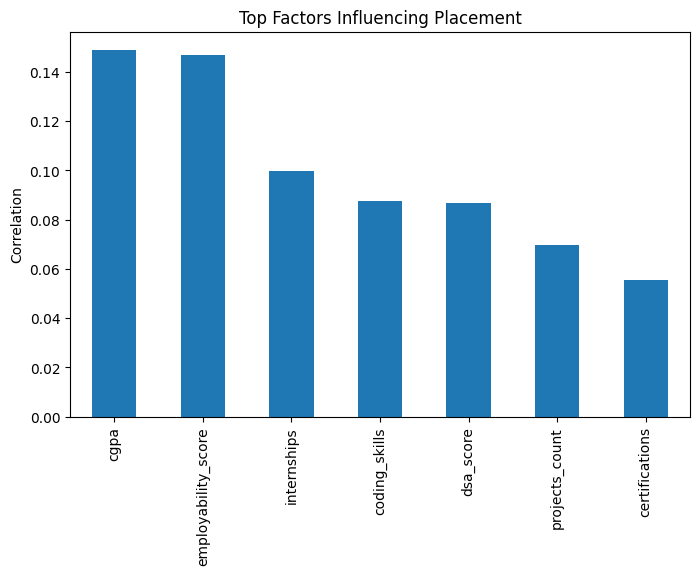

In [15]:
import matplotlib.pyplot as plt

corr[1:8].plot(kind="bar", figsize=(8,5))
plt.title("Top Factors Influencing Placement")
plt.ylabel("Correlation")
plt.show()